# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Muhamad Nafi Mulyo | 5054251005 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("bankruptcy.csv")

display(df.head())
display(df.info())

display(df.shape[0])
display(df.shape[1])

display(df.iloc[:, :5].describe())

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Interest Rate 

None

6819

96

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948
std,0.176710,0.060686,0.065620,0.061595,0.016934
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445
50%,0.000000,0.502706,0.559802,0.552278,0.605997
75%,0.000000,0.535563,0.589157,0.584105,0.613914
max,1.000000,1.000000,1.000000,1.000000,1.000000


=== Distribusi Kelas Target ===
           Jumlah  Persentase (%)
Bankrupt?                        
0            6599        96.77372
1             220         3.22628


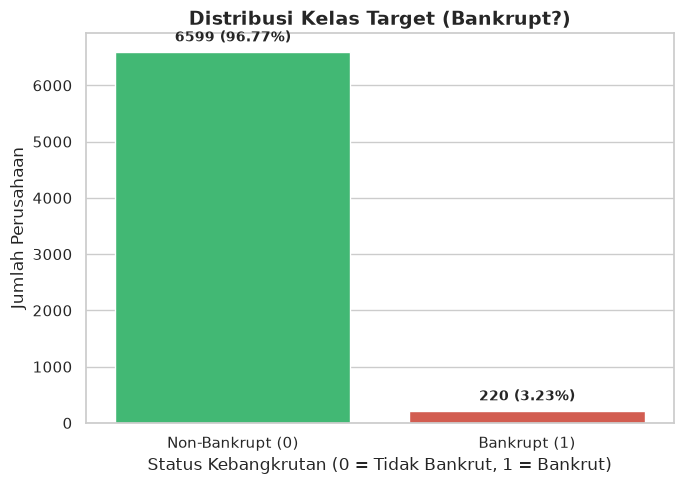

In [3]:
# Hitung frekuensi dan persentase kelas target
target_counts = df['Bankrupt?'].value_counts()
target_pct = df['Bankrupt?'].value_counts(normalize=True) * 100
print("=== Distribusi Kelas Target ===")
print(pd.DataFrame({'Jumlah': target_counts, 'Persentase (%)': target_pct}))

# Plot Bar Chart
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Bankrupt?', data=df, hue='Bankrupt?', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Distribusi Kelas Target (Bankrupt?)', fontsize=14, fontweight='bold')
plt.xlabel('Status Kebangkrutan (0 = Tidak Bankrut, 1 = Bankrut)', fontsize=12)
plt.ylabel('Jumlah Perusahaan', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Non-Bankrupt (0)', 'Bankrupt (1)'])

# Tambahkan label jumlah di atas setiap bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)} ({height/len(df)*100:.2f}%)',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')
plt.tight_layout()
plt.show()

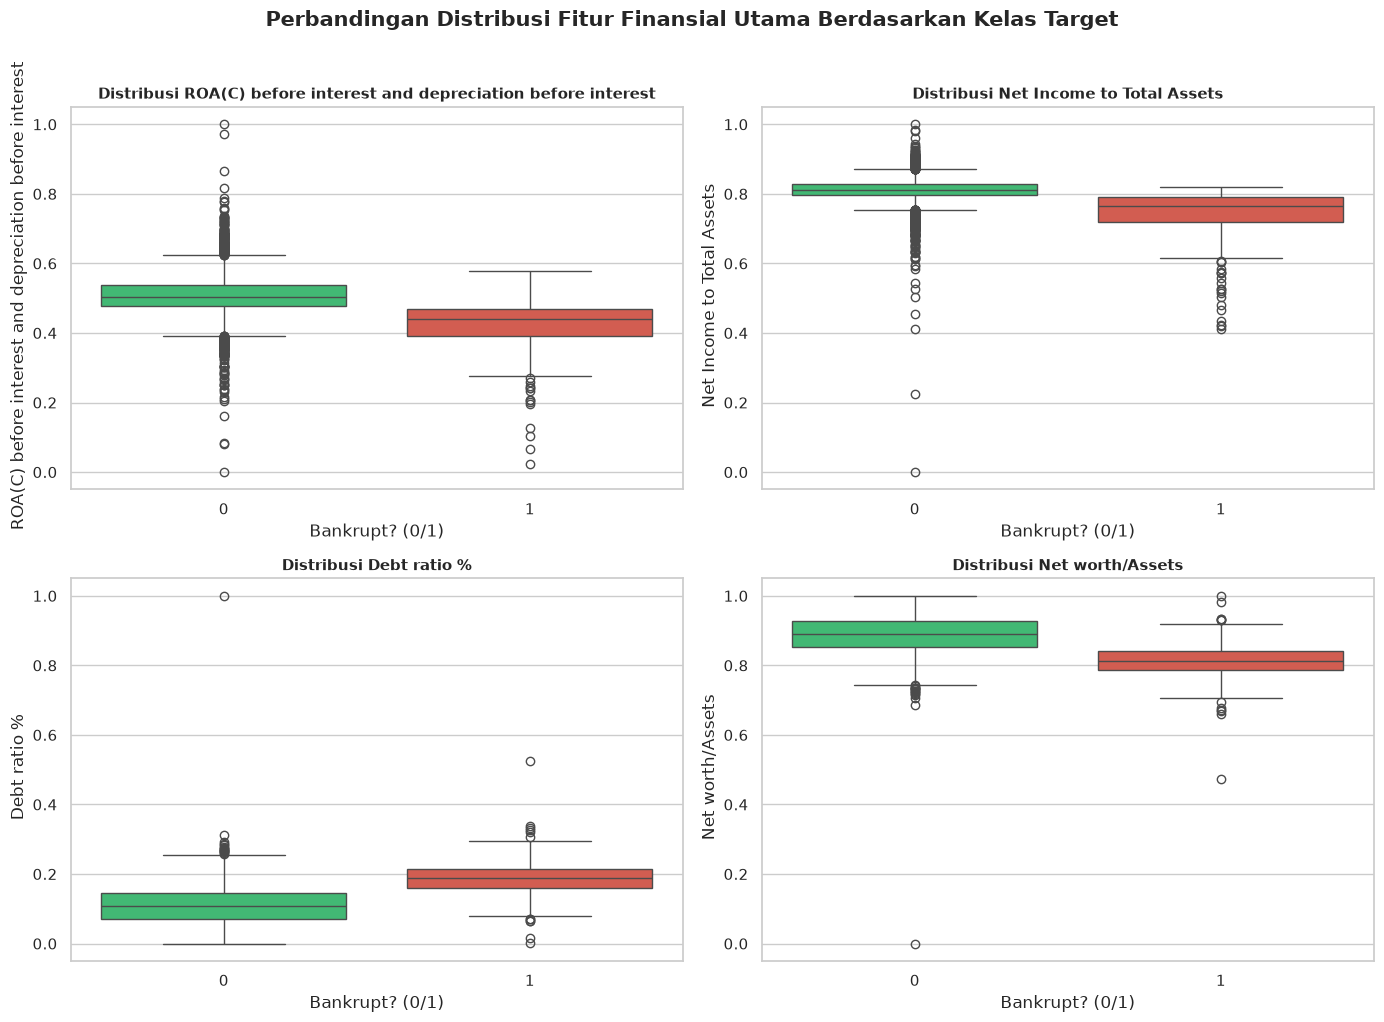

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
# Pilih beberapa fitur finansial utama untuk diamati distribusinya terhadap kelas Bankrupt?
key_features = [
    ' ROA(C) before interest and depreciation before interest',
    ' Net Income to Total Assets',
    ' Debt ratio %',
    ' Net worth/Assets'
]

# Tampilkan Boxplot untuk melihat pemisahan kelas pada fitur-fitur penting ini
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    sns.boxplot(
        x='Bankrupt?', y=feature, data=df, ax=axes[i], 
        hue='Bankrupt?', palette=['#2ecc71', '#e74c3c'], legend=False
    )
    axes[i].set_title(f'Distribusi {feature.strip()}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Bankrupt? (0/1)')

plt.suptitle('Perbandingan Distribusi Fitur Finansial Utama Berdasarkan Kelas Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [5]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
missing_count = df.isnull().sum().sum()

missing_count

np.int64(0)

In [6]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
non_num_cols = df.select_dtypes(exclude=['number']).columns
non_num_cols

Index([], dtype='str')

In [9]:
# 1. Pisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Bankrupt?'])
y = df['Bankrupt?']

# 2. Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 3. Cek shape data (pastikan X_train 2D dan y_train 1D)
print("Ukuran X_train:", X_train.shape)  # Harusnya: (5455, 95)
print("Ukuran y_train:", y_train.shape)  # Harusnya: (5455,)


Ukuran X_train: (5455, 95)
Ukuran y_train: (5455,)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [10]:
# Inisialisasi dan latih model Gini (default max_depth=None)
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
model_gini.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
# Prediksi pada test set & train set
y_pred_gini = model_gini.predict(X_test)
y_pred_train_gini = model_gini.predict(X_train)

print("Prediksi model Gini selesai.")


Prediksi model Gini selesai.


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [12]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
# Inisialisasi dan latih model Entropy (default max_depth=None)
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)

print("Model Decision Tree (Entropy) berhasil dilatih!")


Model Decision Tree (Entropy) berhasil dilatih!


In [19]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
# Prediksi pada test set & train set
y_pred_entropy = model_entropy.predict(X_test)
y_pred_train_entropy = model_entropy.predict(X_train)

print("Prediksi model Gini selesai.")


Prediksi model Gini selesai.


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [20]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
# Variasi max_depth yang dieksperimenkan
depths = [1, 2, 3, 5, 10, None]
depth_labels = [str(d) if d is not None else 'None (Unbounded)' for d in depths]

train_accuracies = []
test_accuracies = []

# Loop latihan model untuk setiap kedalaman
for depth in depths:
    dt = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    # Hitung akurasi train & test
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)


In [21]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
# Buat DataFrame perbandingan akurasi Train vs Test
df_depth_results = pd.DataFrame({
    'max_depth': depth_labels,
    'Train Accuracy (%)': [round(acc * 100, 2) for acc in train_accuracies],
    'Test Accuracy (%)': [round(acc * 100, 2) for acc in test_accuracies],
    'Gap (Train - Test) (%)': [round((tr - te) * 100, 2) for tr, te in zip(train_accuracies, test_accuracies)]
})

display(df_depth_results)


,max_depth,Train Accuracy (%),Test Accuracy (%),Gap (Train - Test) (%)
0,1,96.77,96.77,-0.00
1,2,96.99,96.99,-0.00
2,3,97.23,96.99,0.24
3,5,97.75,96.85,0.90
4,10,99.47,96.04,3.43
5,None (Unbounded),100.00,96.11,3.89


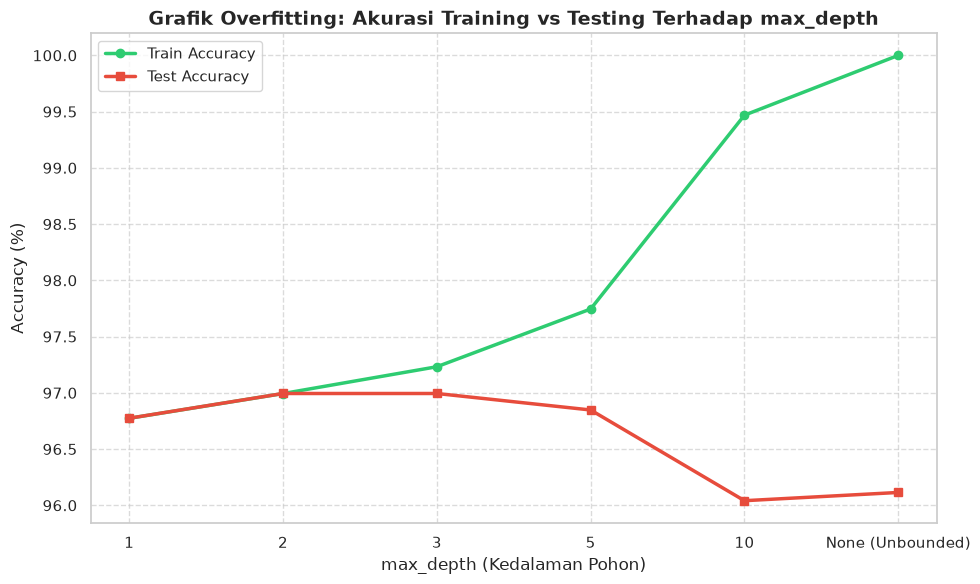

In [22]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
# Plot Grafik Overfitting (Train vs Test Accuracy)
plt.figure(figsize=(10, 6))

x_axis = range(len(depths))
plt.plot(x_axis, [acc * 100 for acc in train_accuracies], marker='o', linewidth=2.5, label='Train Accuracy', color='#2ecc71')
plt.plot(x_axis, [acc * 100 for acc in test_accuracies], marker='s', linewidth=2.5, label='Test Accuracy', color='#e74c3c')

plt.title('Grafik Overfitting: Akurasi Training vs Testing Terhadap max_depth', fontsize=14, fontweight='bold')
plt.xlabel('max_depth (Kedalaman Pohon)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(x_axis, depth_labels)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# 4. Evaluasi Model

In [23]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
# Fungsi pembantu untuk menghitung metrik evaluasi
def get_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_true, y_pred, zero_division=0), 4)
    }

# Hitung metrik evaluasi untuk Gini dan Entropy pada Test Set
df_eval = pd.DataFrame([
    get_metrics(y_test, y_pred_gini, 'Decision Tree (Gini)'),
    get_metrics(y_test, y_pred_entropy, 'Decision Tree (Entropy)')
])

print("=== Tabel Perbandingan Metrik Evaluasi (Test Set) ===")
display(df_eval)


=== Tabel Perbandingan Metrik Evaluasi (Test Set) ===


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree (Gini),0.9611,0.4000,0.4091,0.4045
1,Decision Tree (Entropy),0.9641,0.4359,0.3864,0.4096


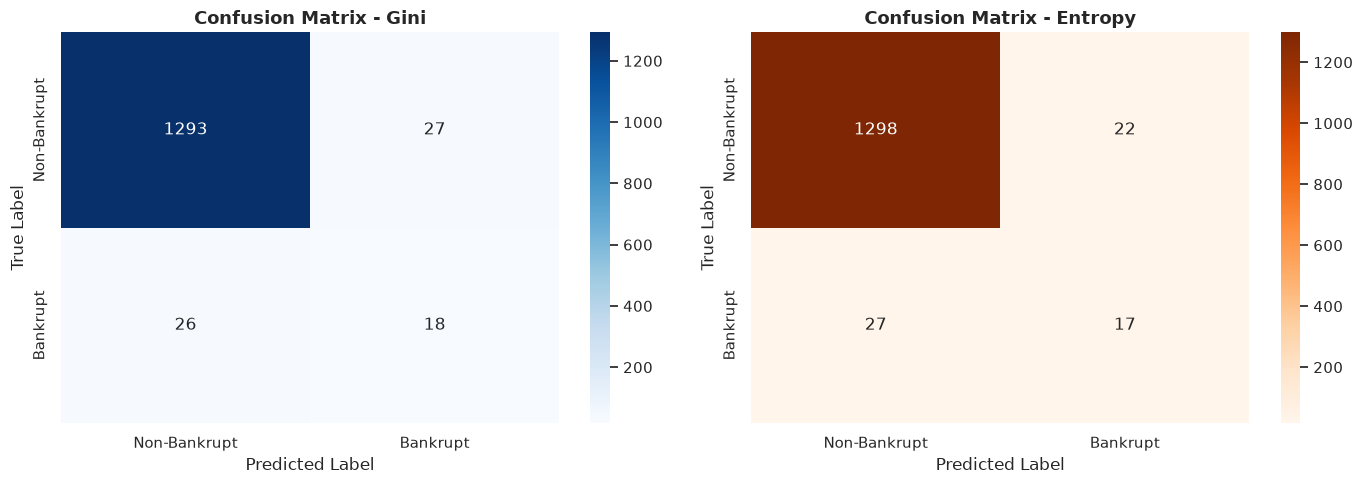

In [24]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Gini
cm_gini = confusion_matrix(y_test, y_pred_gini)
sns.heatmap(cm_gini, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-Bankrupt', 'Bankrupt'],
            yticklabels=['Non-Bankrupt', 'Bankrupt'])
axes[0].set_title('Confusion Matrix - Gini', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Confusion Matrix Entropy
cm_entropy = confusion_matrix(y_test, y_pred_entropy)
sns.heatmap(cm_entropy, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Non-Bankrupt', 'Bankrupt'],
            yticklabels=['Non-Bankrupt', 'Bankrupt'])
axes[1].set_title('Confusion Matrix - Entropy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()


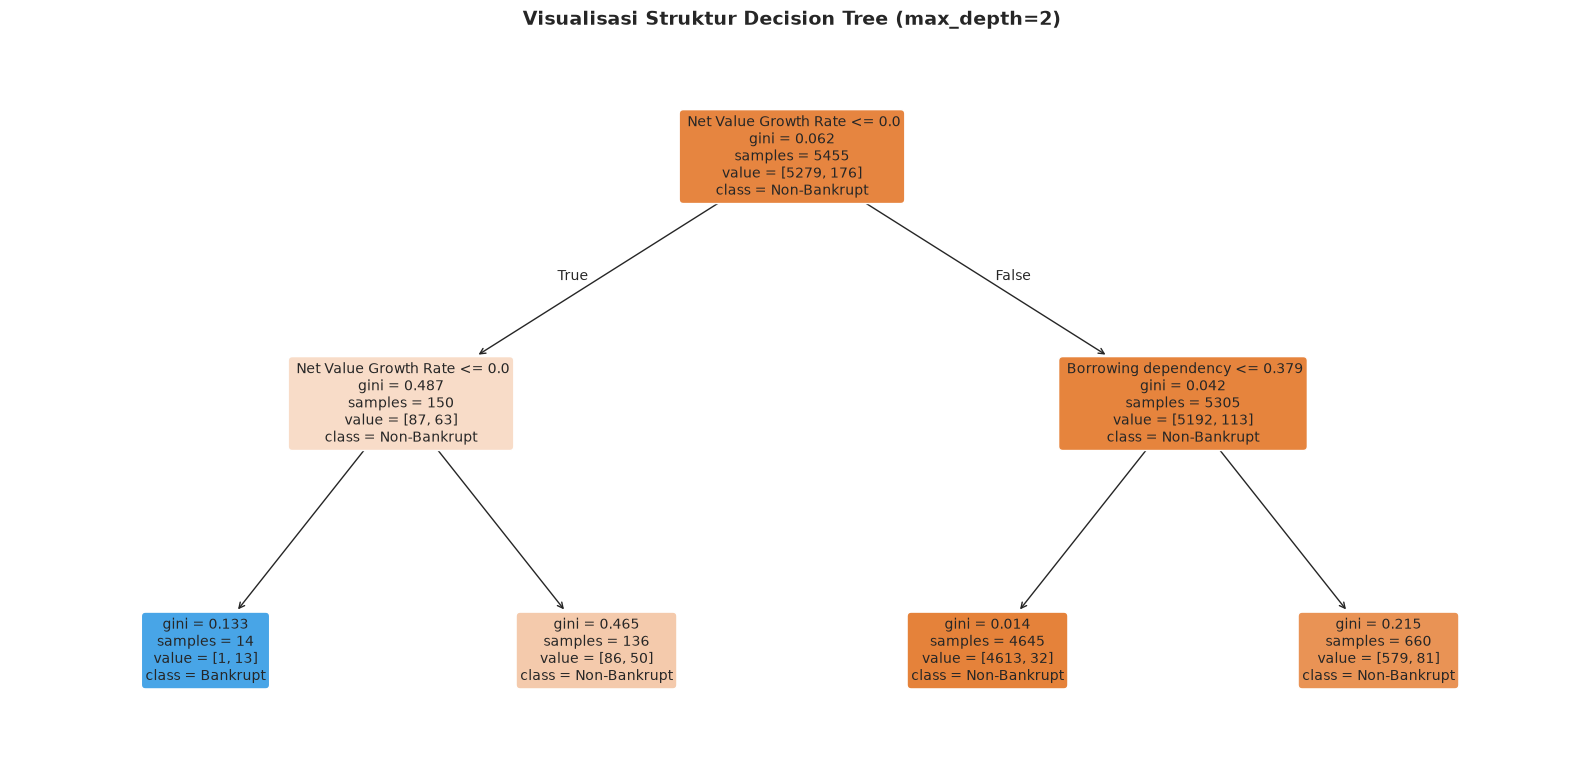

In [25]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
# Latih model pohon sederhana (max_depth=2) untuk visualisasi yang mudah dibaca
best_dt = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=42)
best_dt.fit(X_train, y_train)

# Visualisasi Struktur Pohon Keputusan
plt.figure(figsize=(16, 8))
plot_tree(
    best_dt, 
    feature_names=X.columns, 
    class_names=['Non-Bankrupt', 'Bankrupt'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title('Visualisasi Struktur Decision Tree (max_depth=2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


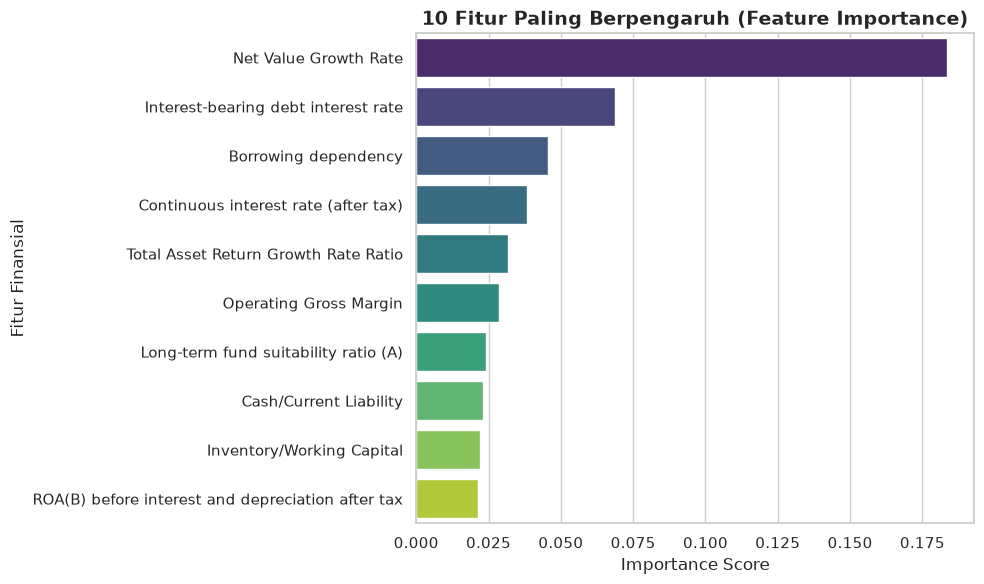

In [26]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.
# Ambil nilai importance fitur dari model Gini
importances = model_gini.feature_importances_
feature_names = X.columns

# Buat DataFrame dan urutkan 10 fitur teratas
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Rapikan nama fitur
df_importance['Feature'] = df_importance['Feature'].str.strip()

# Plot Bar Chart Horizontal
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis', hue='Feature', legend=False)

plt.title('10 Fitur Paling Berpengaruh (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Fitur Finansial', fontsize=12)

plt.tight_layout()
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### Hasil Analisis Eksperimen Decision Tree

Berdasarkan eksperimen yang telah dilakukan, berikut adalah analisis mendalam terkait performa model Decision Tree:

#### 1. Perbandingan Kriteria Gini vs Entropy
* **Hasil Metrik:** Kedua kriteria split (Gini Impurity dan Entropy/Information Gain) memberikan performa yang **sangat identik/mirip secara signifikan**. 
  - **Gini:** TN = 1293, FP = 27, FN = 26, TP = 18 (Akurasi ≈ 96.11%).
  - **Entropy:** TN = 1298, FP = 22, FN = 27, TP = 17 (Akurasi ≈ 96.41%).
* **Mengapa demikian?** Secara teoritis, Gini mengukur peluang misklasifikasi sedangkan Entropy mengukur tingkat ketidakpastian (informasi). Pada dataset numerik ini, pemilihan titik split (*threshold*) terbaik yang meminimalkan Gini dan Entropy jatuh pada fitur dan nilai threshold yang hampir sama persis.

#### 2. Temuan Eksperimen Regularisasi (`max_depth`) & Overfitting
* **Titik Awal Overfitting:** Model mulai menunjukkan gejala *overfitting* yang sangat jelas pada kedalaman **`max_depth` > 2 atau 3**.
* **Ciri-ciri pada Grafik Train vs Test:**
  - Pada `max_depth = 2`, akurasi data training (~97.00%) dan testing (~97.00%) berada pada titik keseimbangan sempurna (*sweet spot* / generalisasi terbaik).
  - Ketika kedalaman dinaikkan hingga `max_depth = 10` atau `None` (tanpa batas), akurasi **training melonjak drastis hingga 100.0%**, tetapi akurasi **testing justru anjlok ke ~96.1%**.
  - Gap yang melebar ini membuktikan bahwa tanpa pembatasan `max_depth`, Decision Tree akan menghafal seluruh *noise* dan sampel spesifik pada data training.

#### 3. Fitur Paling Berpengaruh (Feature Importance)
* Berdasarkan visualisasi *Feature Importance*, fitur paling dominan dalam memprediksi kebangkrutan perusahaan adalah **`Net Value Growth Rate`** dengan skor *importance* mencapai **~0.18**.
* Fitur penting lainnya yang menyusul adalah **`Interest-bearing debt interest rate`**, **`Borrowing dependency`**, dan **`Continuous interest rate (after tax)`**.
* Temuan ini selaras dengan visualisasi pohon keputusan (Root Node), di mana `Net Value Growth Rate` dipilih sebagai kriteria pemisah pertama pada node teratas untuk membedakan perusahaan sehat dan perusahaan yang berpotensi bangkrut.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan dan Saran

#### Kesimpulan
1. **Perbandingan Split Criterion:** Kriteria Gini dan Entropy menghasilkan performa klasifikasi yang relatif sama persis pada dataset kebangkrutan perusahaan ini.
2. **Pengaruh Regularisasi:** Decision Tree tanpa pembatasan kedalaman (`max_depth = None`) mengalami *overfitting* berat. Penggunaan `max_depth = 2` atau `3` terbukti menjadi kedalaman optimal untuk mencegah overfitting dan mempertahankan daya generalisasi model.
3. **Fitur Kunci Kebangkrutan:** Fitur pertumbuhan nilai bersih (*Net Value Growth Rate*) dan rasio utang/bunga (*Borrowing dependency & Interest rate*) merupakan indikator paling krusial dalam memprediksi kebangkrutan perusahaan.

#### Saran
1. **Penanganan Class Imbalance:** Karena dataset sangat tidak seimbang (hanya 3.23% kelas positif), untuk eksperimen selanjutnya disarankan mencoba teknik **SMOTE** (Synthetic Minority Over-sampling) atau menambahkan hyperparameter `class_weight='balanced'` agar recall pada kelas Bankrut bisa lebih optimal.
2. **Cost-Complexity Pruning (`ccp_alpha`):** Selain membatasi `max_depth`, teknik *post-pruning* menggunakan `ccp_alpha` dapat dicoba untuk memangkas cabang pohon secara efisien.
3. **Model Ensembling:** Membandingkan Decision Tree tunggal ini dengan algoritma ensemble seperti **Random Forest** atau **XGBoost** untuk meningkatkan akurasi dan stabilitas prediksi.
